# ETF Target Weight Optimization
### Given Expected Returns → Solve for Optimal Portfolio Weights

This notebook skips historical return estimation entirely. Instead, we **supply forward-looking (analyst) expected returns** directly and ask:

> *"Given these return assumptions, what portfolio weights maximise the Sharpe ratio?"*

The optimization problem is:

$$\max_{\mathbf{w}}\; \frac{\mathbf{w}^\top \boldsymbol{\mu} - r_f}{\sqrt{\mathbf{w}^\top \Sigma\, \mathbf{w}}} \qquad\text{s.t.}\quad \sum_i w_i = 1,\quad 0.04 \leq w_i \leq 0.40$$

where $\boldsymbol{\mu}$ comes from the **user-specified expected returns** below — not from a historical mean.

| Section | Purpose |
|---|---|
| 1 | Setup & Imports |
| 2 | Asset Universe & Expected Returns |
| 3 | Data Fetching (covariance only) |
| 4 | Covariance Matrix |
| 5 | Equal-Weight Baseline |
| 6 | Helper Functions |
| 7 | Max-Sharpe Optimization |
| 8 | Efficient Frontier Sweep |
| 9 | Visualisations |

---
## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

# ── Core data science ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go

# ── Finance data ───────────────────────────────────────────────────────────
import yfinance as yf

# ── SciPy optimization ─────────────────────────────────────────────────────
from scipy.optimize import minimize

# ── Global style ───────────────────────────────────────────────────────────
plt.style.use('fivethirtyeight')

print('All libraries imported successfully.')
print(f'pandas {pd.__version__}  |  numpy {np.__version__}')

All libraries imported successfully.
pandas 3.0.2  |  numpy 2.4.4


---
## 2. Asset Universe & Expected Returns

### Why provide expected returns directly?

Historical mean returns are **notoriously noisy** estimators of future returns — they embed regime-specific noise (e.g. the 2022 rate shock) and require very long sample windows to be reliable. In practice, portfolio managers prefer **forward-looking (analyst) return assumptions** that incorporate:

- Macro regime views (rate path, credit spreads, earnings growth forecasts)
- Valuation metrics (P/E ratios, yield spreads vs. history)
- Strategic asset allocation frameworks (e.g. Black-Litterman blends)

Here we inject those views directly, bypassing historical mean estimation entirely.

> **To update the return assumptions**, change the values in `TARGET_EXPECTED_RETURNS` below.

In [2]:
# ══════════════════════════════════════════════════════════════════════════
#  USER-SUPPLIED FORWARD-LOOKING EXPECTED RETURNS  (annual, decimal)
# ══════════════════════════════════════════════════════════════════════════
TARGET_EXPECTED_RETURNS = {
    'IWV':  0.080,   # US Equity (Russell 3000)          8.0%
    'VCIT': 0.049,   # Investment-Grade Corp Bond         4.9%
    'SPTL': 0.051,   # Long-Term Government Bond          5.1%
    'VEA':  0.079,   # Developed Non-US Equity            7.9%
    'IEMG': 0.080,   # Emerging Market Equity             8.0%
    'TIP':  0.047,   # TIPS (Inflation-Protected Bond)    4.7%
    'JNK':  0.066,   # High-Yield Bond                    6.6%
}

# Risk-free rate
RISK_FREE_RATE = 0.05   # 5.0%
# ══════════════════════════════════════════════════════════════════════════

tickers = list(TARGET_EXPECTED_RETURNS.keys())
n       = len(tickers)

ticker_labels = {
    'IWV':  'US Equity (Russell 3000)',
    'VCIT': 'Investment-Grade Corp Bond',
    'SPTL': 'Long-Term Government Bond',
    'VEA':  'Developed Non-US Equity',
    'IEMG': 'Emerging Market Equity',
    'TIP':  'Inflation-Protected Bond',
    'JNK':  'High-Yield Bond',
}

# Build the μ vector as a pandas Series (keeps labels throughout)
exp_returns = pd.Series(TARGET_EXPECTED_RETURNS)

print('━' * 58)
print('  User-Supplied Forward-Looking Expected Returns')
print('━' * 58)
for t, er in exp_returns.items():
    bar = '█' * int(er * 200)
    print(f'  {t:<6}  {er:>6.2%}  {bar:<14}  {ticker_labels[t]}')
print('━' * 58)
print(f'  Risk-Free Rate  : {RISK_FREE_RATE:.2%}')
print(f'  Return range    : {exp_returns.min():.2%}  →  {exp_returns.max():.2%}')
print(f'  Excess return range (over Rf): '
      f'{(exp_returns - RISK_FREE_RATE).min():.2%}  →  '
      f'{(exp_returns - RISK_FREE_RATE).max():.2%}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  User-Supplied Forward-Looking Expected Returns
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  IWV      8.00%  ████████████████  US Equity (Russell 3000)
  VCIT     4.90%  █████████       Investment-Grade Corp Bond
  SPTL     5.10%  ██████████      Long-Term Government Bond
  VEA      7.90%  ███████████████  Developed Non-US Equity
  IEMG     8.00%  ████████████████  Emerging Market Equity
  TIP      4.70%  █████████       Inflation-Protected Bond
  JNK      6.60%  █████████████   High-Yield Bond
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Risk-Free Rate  : 5.00%
  Return range    : 4.70%  →  8.00%
  Excess return range (over Rf): -0.30%  →  3.00%


---
## 3. Data Fetching (covariance inputs only)

We still need **historical price data** to estimate the **covariance matrix** $\Sigma$ — the risk structure of the portfolio. Only the mean return vector $\boldsymbol{\mu}$ is replaced by our analyst views; the co-movement structure is still estimated from realised data.

This is standard practice: means are replaced by views; covariances are kept historical because they are statistically more stable and harder to estimate from first principles alone.

In [3]:
START = '2021-01-01'
END   = pd.Timestamp.today().strftime('%Y-%m-%d')

print(f'Downloading price data  :  {START}  →  {END}')
print(f'Purpose                 :  covariance matrix estimation only')
print(f'Expected returns        :  user-supplied (NOT from this data)\n')

raw  = yf.download(tickers, start=START, end=END, auto_adjust=True)
data = raw['Close'][tickers]

print(f'Shape      :  {data.shape}  ({data.shape[0]} trading days × {data.shape[1]} ETFs)')
print(f'Date range :  {data.index[0].date()}  →  {data.index[-1].date()}')
print(f'\nMissing values:')
print(data.isnull().sum().to_string())

Purpose                 :  covariance matrix estimation only
Expected returns        :  user-supplied (NOT from this data)



[*********************100%***********************]  7 of 7 completed


Shape      :  (1350, 7)  (1350 trading days × 7 ETFs)
Date range :  2021-01-04  →  2026-05-19

Missing values:
Ticker
IWV     0
VCIT    0
SPTL    0
VEA     0
IEMG    0
TIP     0
JNK     0


---
## 4. Covariance Matrix

The **annualised covariance matrix** $\Sigma$ is estimated from daily log returns scaled by 252 trading days. This captures real cross-asset correlations — including the 2022 episode where equities and long-duration bonds fell simultaneously — giving the optimizer a realistic risk picture to work against.

In [4]:
TRADING_DAYS = 252

log_returns = np.log(data).diff().dropna()
cov_matrix  = log_returns.cov() * TRADING_DAYS

# Individual volatilities from historical data
hist_vols = log_returns.std() * np.sqrt(TRADING_DAYS)

print('Annualised Covariance Matrix (daily log-return cov × 252):')
display(cov_matrix.round(6))

Annualised Covariance Matrix (daily log-return cov × 252):


Ticker,IWV,VCIT,SPTL,VEA,IEMG,TIP,JNK
Ticker,,,,,,,
IWV,0.029231,0.003933,0.001846,0.022966,0.022095,0.002101,0.009639
VCIT,0.003933,0.004213,0.007962,0.004154,0.003661,0.003160,0.003217
SPTL,0.001846,0.007962,0.021024,0.002788,0.002276,0.006736,0.004182
VEA,0.022966,0.004154,0.002788,0.026740,0.024996,0.002367,0.008544
IEMG,0.022095,0.003661,0.002276,0.024996,0.034011,0.001810,0.008044
TIP,0.002101,0.003160,0.006736,0.002367,0.001810,0.003769,0.002093
JNK,0.009639,0.003217,0.004182,0.008544,0.008044,0.002093,0.005424


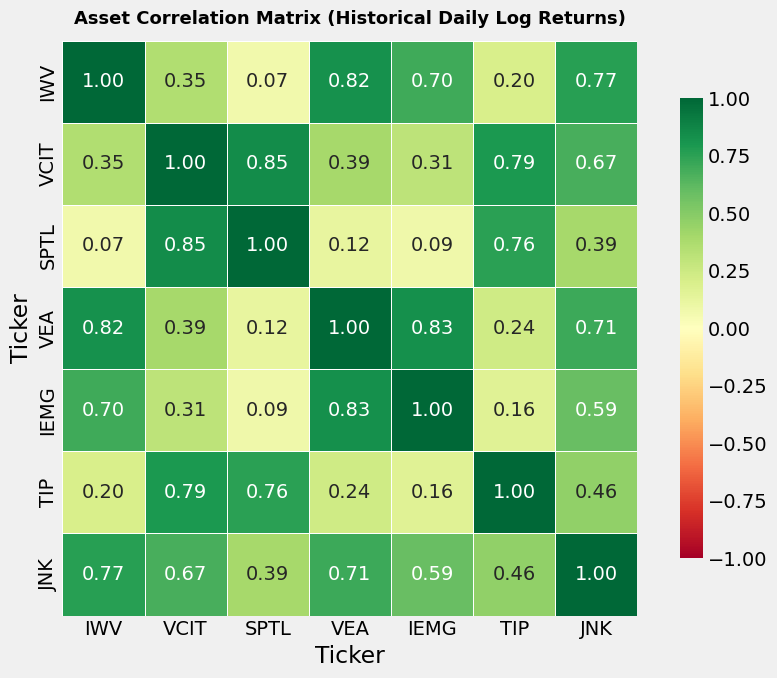

In [5]:
# ── Correlation heatmap ───────────────────────────────────────────────────
corr_matrix = log_returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Asset Correlation Matrix (Historical Daily Log Returns)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [6]:
# ── Per-asset summary: analyst return vs historical vol ───────────────────
summary_df = pd.DataFrame({
    'Asset Class':          pd.Series(ticker_labels),
    'Analyst Exp Return':   exp_returns.map('{:.2%}'.format),
    'Historical Vol (ann)': hist_vols.map('{:.2%}'.format),
    'Implied Sharpe':       ((exp_returns - RISK_FREE_RATE) / hist_vols).map('{:.3f}'.format),
})

print(f'Per-Asset View Summary  (Rf = {RISK_FREE_RATE:.2%})')
display(summary_df)
print()
print('Note: "Implied Sharpe" is a stand-alone metric — it ignores cross-asset')
print('correlations. The optimizer uses the full covariance matrix.')

Per-Asset View Summary  (Rf = 5.00%)


,Asset Class,Analyst Exp Return,Historical Vol (ann),Implied Sharpe
IWV,US Equity (Russell 3000),8.00%,17.10%,0.175
VCIT,Investment-Grade Corp Bond,4.90%,6.49%,-0.015
SPTL,Long-Term Government Bond,5.10%,14.50%,0.007
VEA,Developed Non-US Equity,7.90%,16.35%,0.177
IEMG,Emerging Market Equity,8.00%,18.44%,0.163
TIP,Inflation-Protected Bond,4.70%,6.14%,-0.049
JNK,High-Yield Bond,6.60%,7.36%,0.217



Note: "Implied Sharpe" is a stand-alone metric — it ignores cross-asset
correlations. The optimizer uses the full covariance matrix.


---
## 5. Equal-Weight Baseline

The **1/N equal-weight portfolio** serves as the benchmark against which the optimized portfolio must prove its worth. Its metrics now use the analyst expected returns — not historical means — so any performance gain is purely attributable to better weight allocation, not data differences.

In [7]:
eq_weights = np.array([1 / n] * n)

eq_ret    = float(np.dot(eq_weights, exp_returns.values))
eq_var    = float(eq_weights.T @ cov_matrix.values @ eq_weights)
eq_vol    = np.sqrt(eq_var)
eq_sharpe = (eq_ret - RISK_FREE_RATE) / eq_vol

print('━' * 52)
print('  Equal-Weight Baseline  (1/N)')
print('━' * 52)
print(f'  Weight per asset    : {1/n:.4f}  ({1/n:.2%})')
print(f'  Expected Return     : {eq_ret:.2%}  ← analyst μ')
print(f'  Portfolio Volatility: {eq_vol:.2%}  ← historical Σ')
print(f'  Sharpe Ratio        : {eq_sharpe:.3f}  (Rf = {RISK_FREE_RATE:.2%})')
print('━' * 52)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Equal-Weight Baseline  (1/N)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Weight per asset    : 0.1429  (14.29%)
  Expected Return     : 6.46%  ← analyst μ
  Portfolio Volatility: 9.28%  ← historical Σ
  Sharpe Ratio        : 0.157  (Rf = 5.00%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## 6. Helper Functions

The same three-function structure from the original notebook, now operating on the analyst $\boldsymbol{\mu}$ vector.

| Function | Objective |
|---|---|
| `port_metrics(w)` | Returns `(return, vol, sharpe)` for any weight vector |
| `neg_sharpe(w)` | Negative Sharpe — minimising this **maximises** the Sharpe ratio |
| `check_sum(w)` | Equality constraint: $\sum w_i = 1$ |

In [ ]:
def port_metrics(weights):
    """Return (expected_return, volatility, sharpe_ratio) for a weight vector.
    Uses analyst expected returns (exp_returns) and historical covariance (cov_matrix).
    """
    w    = np.array(weights)
    def port_metrics(weights):
        """Return (expected_return, volatility, sharpe_ratio) for a weight vector.
        Uses analyst expected returns (exp_returns) and historical covariance (cov_matrix).
        """
        w = np.asarray(weights, dtype=float)
        ret = float(np.dot(w, exp_returns.to_numpy(dtype=float)))
        vol = float(np.sqrt(w.T @ cov_matrix.values @ w))
        shrp = (ret - RISK_FREE_RATE) / vol
        return ret, vol, shrp


    def neg_sharpe(weights):
        """Objective: negative Sharpe ratio.  Minimising this maximises Sharpe."""
        return -port_metrics(weights)[2]


    def check_sum(weights):
        """Equality constraint: fully invested (weights sum to 1)."""
        return np.sum(weights) - 1.0


    # ── Sanity check: equal-weight port via helper ────────────────────────────
    r_chk, v_chk, s_chk = port_metrics(eq_weights)
    assert abs(r_chk - eq_ret) < 1e-10 and abs(v_chk - eq_vol) < 1e-10, \
        'Helper function mismatch vs Section 5 — check inputs.'
    print('Helper functions validated against equal-weight baseline ✓')
    vol  = float(np.sqrt(w.T @ cov_matrix.values @ w))
    shrp = (ret - RISK_FREE_RATE) / vol
    return ret, vol, shrp


def neg_sharpe(weights):
    """Objective: negative Sharpe ratio.  Minimising this maximises Sharpe."""
    return -port_metrics(weights)[2]


def check_sum(weights):
    """Equality constraint: fully invested (weights sum to 1)."""
    return np.sum(weights) - 1.0


# ── Sanity check: equal-weight port via helper ────────────────────────────
r_chk, v_chk, s_chk = port_metrics(eq_weights)
assert abs(r_chk - eq_ret) < 1e-10 and abs(v_chk - eq_vol) < 1e-10, \
    'Helper function mismatch vs Section 5 — check inputs.'
print('Helper functions validated against equal-weight baseline ✓')

Helper functions validated against equal-weight baseline ✓


---
## 7. Max-Sharpe Optimization

### Optimization formulation

$$\max_{\mathbf{w}}\; \frac{\mathbf{w}^\top \boldsymbol{\mu} - r_f}{\sqrt{\mathbf{w}^\top \Sigma\, \mathbf{w}}} \qquad\text{subject to}\qquad \sum_{i=1}^{n} w_i = 1,\quad 0.04 \leq w_i \leq 0.40 \quad\forall\, i$$

where:
- $\boldsymbol{\mu}$ = analyst-supplied expected returns (Section 2)
- $\Sigma$ = historical annualised covariance matrix (Section 4)
- $r_f = 0.5\%$ (user-specified risk-free rate)

**Position bounds rationale:**
- **Minimum 4%** — every ETF must have a meaningful allocation; purely nominal positions are excluded.
- **Maximum 24%** — limits single-asset-class concentration; guards against over-fitting to a high-return assumption.

In [9]:
W_MIN, W_MAX = 0.04, 0.24

bounds      = tuple((W_MIN, W_MAX) for _ in range(n))
constraints = ({'type': 'eq', 'fun': check_sum},)
x0          = eq_weights.copy()   # warm-start from feasible equal-weight point

result = minimize(
    fun=neg_sharpe,
    x0=x0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-14, 'maxiter': 5_000}
)

print(f'Optimization success  : {result.success}')
print(f'Solver message        : {result.message}')
print(f'Iterations            : {result.nit}')
print(f'Function evaluations  : {result.nfev}')

Optimization success  : True
Solver message        : Optimization terminated successfully
Iterations            : 7
Function evaluations  : 56


In [10]:
assert result.success, (
    f'Optimization did not converge: {result.message}. '
    'Check that the covariance matrix is positive definite and that '
    'bounds are feasible.'
)

opt_weights              = result.x
opt_ret, opt_vol, opt_sharpe = port_metrics(opt_weights)

# ── Detailed results table ────────────────────────────────────────────────
print('━' * 70)
print('  Max-Sharpe Portfolio  —  Analyst Expected Returns  |  Rf = 5.0%')
print('━' * 70)
print(f'  {"Ticker":<6}  {"Analyst μ":>9}  {"Weight":>8}   Bar                 Asset class')
print('  ' + '─' * 67)
for ticker, w in zip(tickers, opt_weights):
    mu    = TARGET_EXPECTED_RETURNS[ticker]
    bar   = '█' * int(round(w * 50))
    bound = '  ▼ MIN' if abs(w - W_MIN) < 1e-4 else ('  ▲ MAX' if abs(w - W_MAX) < 1e-4 else '')
    print(f'  {ticker:<6}  {mu:>9.2%}  {w:>8.3f}   {w:.2%}  {bar:<20}  {ticker_labels[ticker]}{bound}')
print('  ' + '─' * 67)
print(f'  {"TOTAL":<6}  {"":>9}  {opt_weights.sum():>8.3f}   {opt_weights.sum():.2%}')
print('━' * 70)
print(f'  Expected Return      : {opt_ret:.4%}')
print(f'  Portfolio Volatility : {opt_vol:.4%}')
print(f'  Sharpe Ratio         : {opt_sharpe:.4f}  (Rf = {RISK_FREE_RATE:.2%})')
print('━' * 70)
print(f'\n  Δ vs equal-weight baseline:')
print(f'  Return   : {opt_ret - eq_ret:+.2%}')
print(f'  Vol      : {opt_vol - eq_vol:+.2%}')
print(f'  Sharpe   : {opt_sharpe - eq_sharpe:+.4f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Max-Sharpe Portfolio  —  Analyst Expected Returns  |  Rf = 0.50%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ticker  Analyst μ    Weight   Bar                 Asset class
  ───────────────────────────────────────────────────────────────────
  IWV         8.00%     0.240   24.00%  ████████████          US Equity (Russell 3000)  ▲ MAX
  VCIT        4.90%     0.040   4.00%  ██                    Investment-Grade Corp Bond  ▼ MIN
  SPTL        5.10%     0.040   4.00%  ██                    Long-Term Government Bond  ▼ MIN
  VEA         7.90%     0.240   24.00%  ████████████          Developed Non-US Equity  ▲ MAX
  IEMG        8.00%     0.160   16.00%  ████████              Emerging Market Equity
  TIP         4.70%     0.040   4.00%  ██                    Inflation-Protected Bond  ▼ MIN
  JNK         6.60%     0.240   24.00%  ████████████          High-Yield Bond  ▲ MAX
  ────────────────

### Reading the bound flags

| Flag | Meaning |
|---|---|
| `▼ MIN` | Optimizer would exclude this ETF entirely if unconstrained — its risk/return contribution at the margin is too poor |
| `▲ MAX` | Optimizer would allocate more if unconstrained — this is the primary Sharpe driver |
| `free ○` | Weight is an interior solution — the optimizer balanced marginal Sharpe contribution exactly at this level |

---
## 8. Efficient Frontier Sweep

By solving the **minimum-variance problem** for a range of target returns, we trace the full efficient frontier using our analyst $\boldsymbol{\mu}$ and historical $\Sigma$. The tangency point (maximum Sharpe) should coincide with the solution from Section 7.

In [11]:
def min_variance_for_target(target_return):
    """Solve for minimum-variance weights that achieve a specific return target."""
    cons = [
        {'type': 'eq', 'fun': check_sum},
        {'type': 'eq', 'fun': lambda w: float(np.dot(w, exp_returns.values)) - target_return},
    ]
    res = minimize(
        fun=lambda w: float(np.array(w).T @ cov_matrix.values @ np.array(w)),
        x0=eq_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=cons,
        options={'ftol': 1e-13, 'maxiter': 3_000}
    )
    return res


# ── Sweep ─────────────────────────────────────────────────────────────────
target_range = np.linspace(
    exp_returns.min() * 1.005,
    exp_returns.max() * 0.995,
    100
)

f_rets, f_vols, f_sharpes, f_weights = [], [], [], []

for t in target_range:
    res = min_variance_for_target(t)
    if res.success:
        r, v, s = port_metrics(res.x)
        f_rets.append(r)
        f_vols.append(v)
        f_sharpes.append(s)
        f_weights.append(res.x)

f_rets    = np.array(f_rets)
f_vols    = np.array(f_vols)
f_sharpes = np.array(f_sharpes)
f_weights = np.array(f_weights)

gmv_idx  = np.argmin(f_vols)
tang_idx = np.argmax(f_sharpes)

print(f'Frontier points      : {len(f_rets)}')
print(f'GMV portfolio        : Return {f_rets[gmv_idx]:.2%},  Vol {f_vols[gmv_idx]:.2%},  Sharpe {f_sharpes[gmv_idx]:.3f}')
print(f'Tangency portfolio   : Return {f_rets[tang_idx]:.2%},  Vol {f_vols[tang_idx]:.2%},  Sharpe {f_sharpes[tang_idx]:.3f}')
print(f'Opt weights (Sec 7)  : Return {opt_ret:.2%},  Vol {opt_vol:.2%},  Sharpe {opt_sharpe:.3f}')

Frontier points      : 57
GMV portfolio        : Return 5.74%,  Vol 7.08%,  Sharpe 0.104
Tangency portfolio   : Return 7.27%,  Vol 11.91%,  Sharpe 0.191
Opt weights (Sec 7)  : Return 7.27%,  Vol 11.87%,  Sharpe 0.191


---
## 9. Visualisations

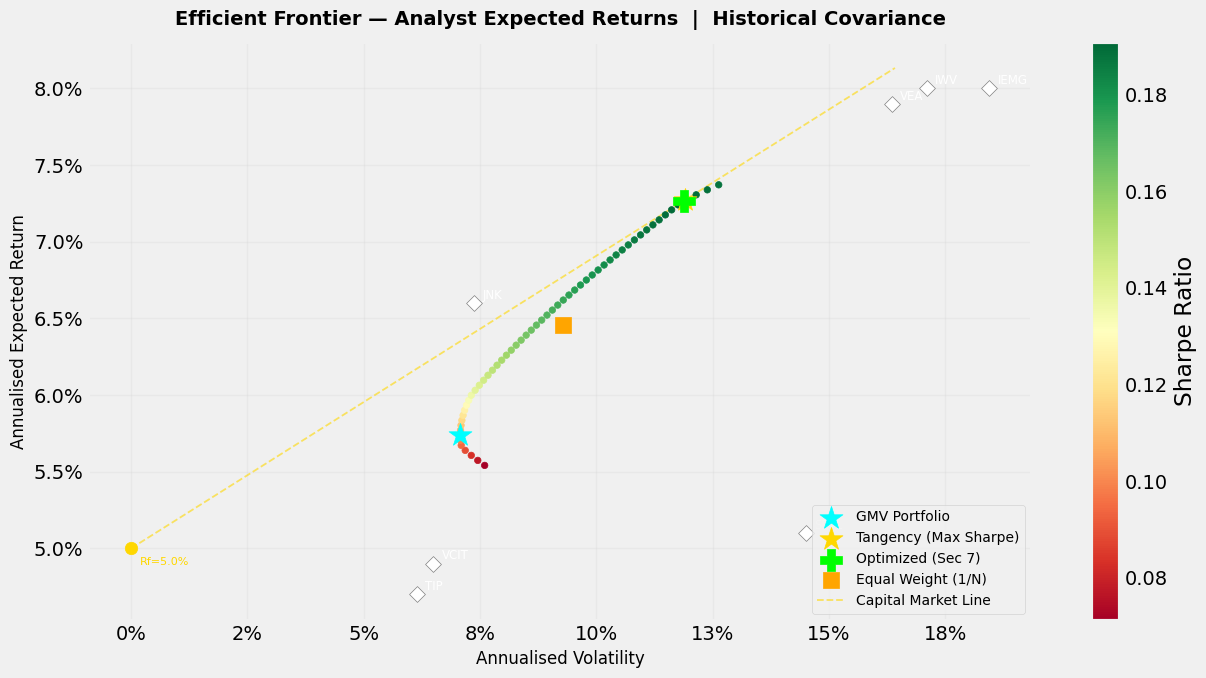

In [12]:
# ── 9a. Efficient Frontier ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

sc = ax.scatter(
    f_vols, f_rets,
    c=f_sharpes, cmap='RdYlGn', s=22, zorder=3, label='_'
)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# Individual ETF dots (analyst μ vs historical vol)
for t in tickers:
    ax.scatter(hist_vols[t], exp_returns[t],
               marker='D', s=65, color='white', edgecolors='grey', zorder=4)
    ax.annotate(t, (hist_vols[t], exp_returns[t]),
                textcoords='offset points', xytext=(6, 3), fontsize=8.5, color='white')

# Special portfolios
ax.scatter(f_vols[gmv_idx], f_rets[gmv_idx],
           marker='*', s=300, color='cyan', zorder=5, label='GMV Portfolio')
ax.scatter(f_vols[tang_idx], f_rets[tang_idx],
           marker='*', s=300, color='gold', zorder=5, label='Tangency (Max Sharpe)')
ax.scatter(opt_vol, opt_ret,
           marker='P', s=260, color='lime', zorder=6, label='Optimized (Sec 7)')
ax.scatter(eq_vol, eq_ret,
           marker='s', s=130, color='orange', zorder=5, label='Equal Weight (1/N)')

# Capital Market Line
vol_range = np.linspace(0, max(f_vols) * 1.3, 200)
cml = RISK_FREE_RATE + (f_rets[tang_idx] - RISK_FREE_RATE) / f_vols[tang_idx] * vol_range
ax.plot(vol_range, cml, '--', color='gold', linewidth=1.3, alpha=0.6, label='Capital Market Line')
ax.scatter(0, RISK_FREE_RATE, marker='o', s=80, color='gold', zorder=5)
ax.annotate(f'Rf={RISK_FREE_RATE:.1%}', (0, RISK_FREE_RATE),
            textcoords='offset points', xytext=(6, -12), fontsize=8, color='gold')

ax.set_title('Efficient Frontier — Analyst Expected Returns  |  Historical Covariance',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Annualised Volatility', fontsize=12)
ax.set_ylabel('Annualised Expected Return', fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

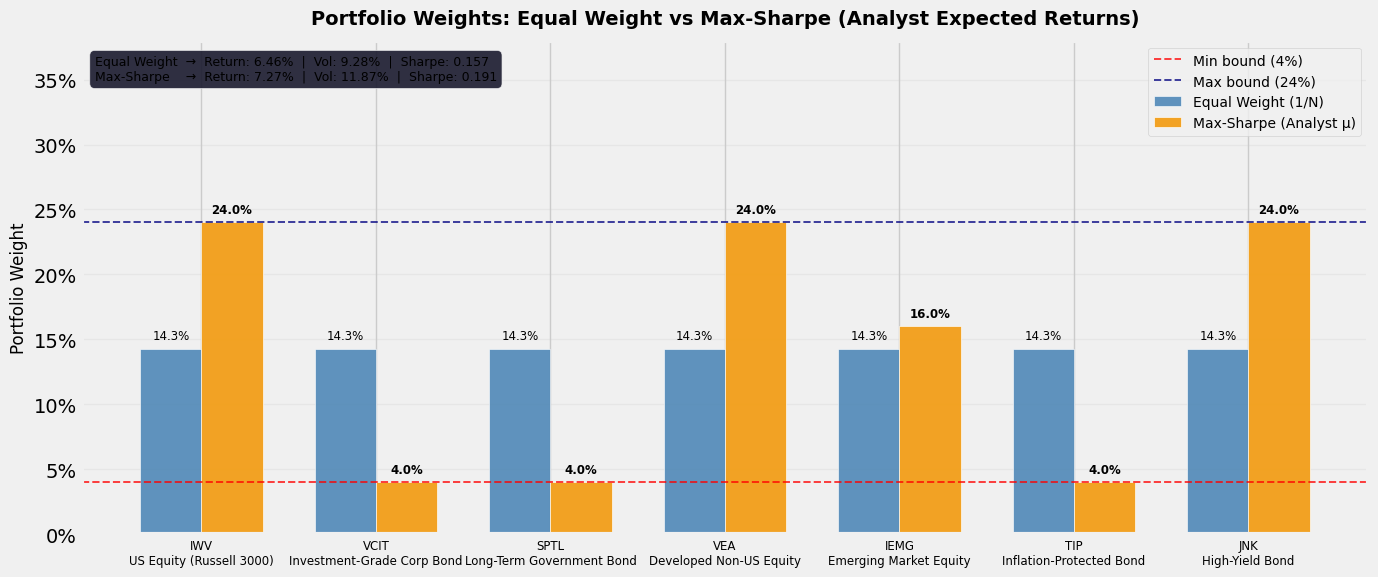

In [13]:
# ── 9b. Weight bar chart: equal-weight vs optimized ───────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

x     = np.arange(n)
width = 0.35

bars_eq  = ax.bar(x - width / 2, eq_weights,  width,
                  label='Equal Weight (1/N)',
                  color='steelblue', alpha=0.85, edgecolor='white')
bars_opt = ax.bar(x + width / 2, opt_weights,  width,
                  label='Max-Sharpe (Analyst μ)',
                  color='#f39c12', alpha=0.92, edgecolor='white')

ax.axhline(y=W_MIN, color='red',  linestyle='--', linewidth=1.4,
           alpha=0.75, label=f'Min bound ({W_MIN:.0%})')
ax.axhline(y=W_MAX, color='navy', linestyle='--', linewidth=1.4,
           alpha=0.75, label=f'Max bound ({W_MAX:.0%})')

for bar, w in zip(bars_eq, eq_weights):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{w:.1%}', ha='center', va='bottom', fontsize=8.5)

for bar, w in zip(bars_opt, opt_weights):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{w:.1%}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(
    [f'{t}\n{ticker_labels[t]}' for t in tickers], fontsize=8.5)
ax.set_title('Portfolio Weights: Equal Weight vs Max-Sharpe (Analyst Expected Returns)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Portfolio Weight', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, W_MAX + 0.14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, axis='y', alpha=0.25)

ann_text = (
    f'Equal Weight  →  Return: {eq_ret:.2%}  |  Vol: {eq_vol:.2%}  |  Sharpe: {eq_sharpe:.3f}\n'
    f'Max-Sharpe    →  Return: {opt_ret:.2%}  |  Vol: {opt_vol:.2%}  |  Sharpe: {opt_sharpe:.3f}'
)
ax.annotate(ann_text, xy=(0.01, 0.97), xycoords='axes fraction',
            fontsize=9, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a2e', alpha=0.90))

plt.tight_layout()
plt.show()

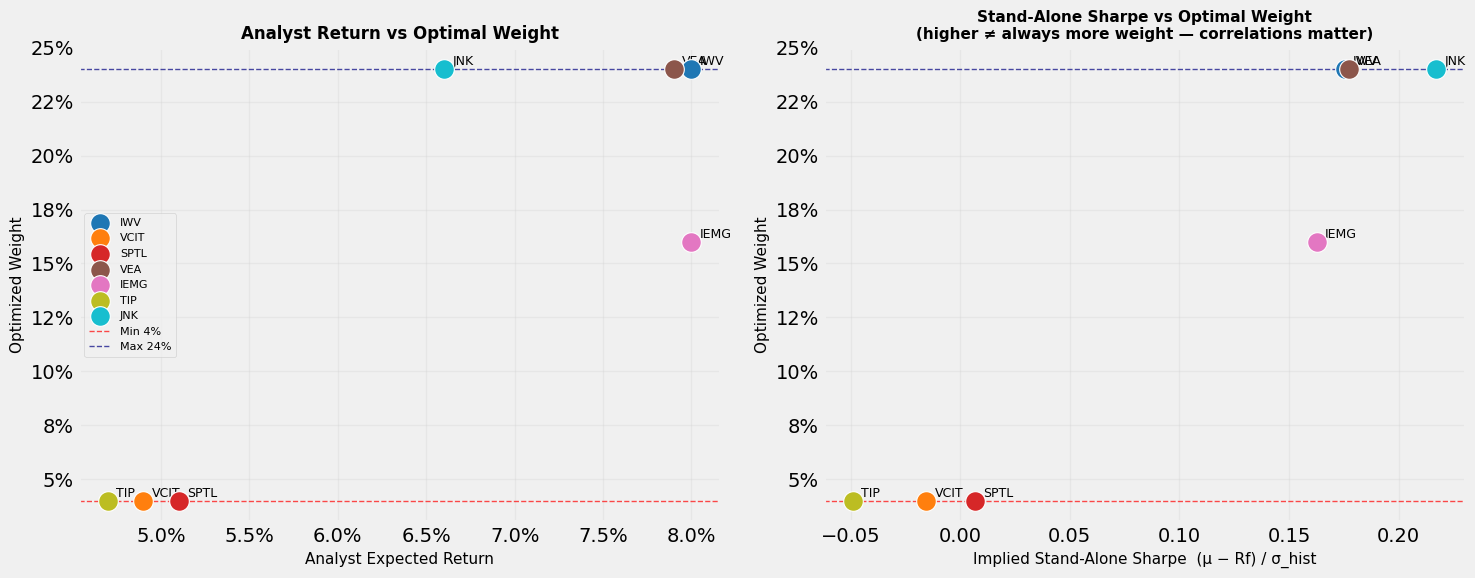

In [14]:
# ── 9c. Analyst return vs optimized weight scatter ────────────────────────
# Shows the relationship between our return inputs and the resulting allocations

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Analyst μ vs Optimal Weight
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, n))
for i, (t, w) in enumerate(zip(tickers, opt_weights)):
    ax.scatter(TARGET_EXPECTED_RETURNS[t], w, s=200, color=colors[i],
               zorder=4, label=t, edgecolors='white', linewidth=0.8)
    ax.annotate(t, (TARGET_EXPECTED_RETURNS[t], w),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.axhline(W_MIN, color='red',  linestyle='--', linewidth=1, alpha=0.7, label=f'Min {W_MIN:.0%}')
ax.axhline(W_MAX, color='navy', linestyle='--', linewidth=1, alpha=0.7, label=f'Max {W_MAX:.0%}')
ax.set_xlabel('Analyst Expected Return', fontsize=11)
ax.set_ylabel('Optimized Weight', fontsize=11)
ax.set_title('Analyst Return vs Optimal Weight', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# Right: Implied stand-alone Sharpe vs Optimized Weight
ax2 = axes[1]
implied_sharpes = (exp_returns - RISK_FREE_RATE) / hist_vols
for i, (t, w) in enumerate(zip(tickers, opt_weights)):
    ax2.scatter(implied_sharpes[t], w, s=200, color=colors[i],
                zorder=4, label=t, edgecolors='white', linewidth=0.8)
    ax2.annotate(t, (implied_sharpes[t], w),
                 textcoords='offset points', xytext=(6, 3), fontsize=9)

ax2.axhline(W_MIN, color='red',  linestyle='--', linewidth=1, alpha=0.7)
ax2.axhline(W_MAX, color='navy', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xlabel('Implied Stand-Alone Sharpe  (μ − Rf) / σ_hist', fontsize=11)
ax2.set_ylabel('Optimized Weight', fontsize=11)
ax2.set_title('Stand-Alone Sharpe vs Optimal Weight\n(higher ≠ always more weight — correlations matter)',
              fontsize=11, fontweight='bold')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

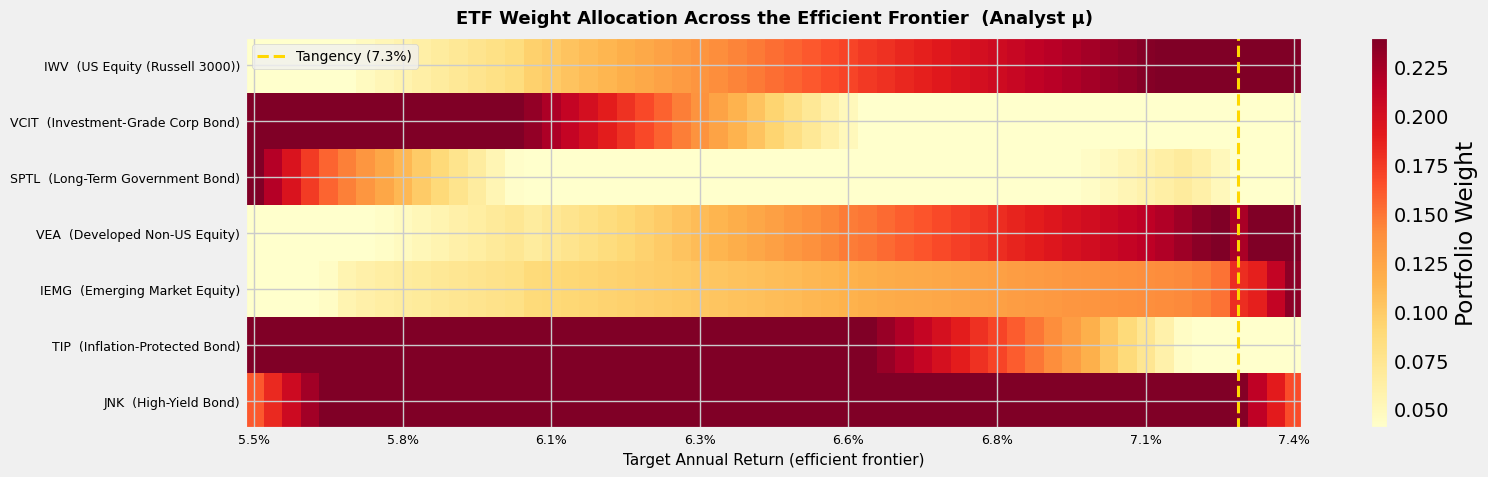

In [15]:
# ── 9d. Weight heatmap across the efficient frontier ──────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(
    f_weights.T,
    aspect='auto',
    cmap='YlOrRd',
    vmin=W_MIN,
    vmax=W_MAX,
    interpolation='nearest'
)

n_ticks  = 8
tick_idx = np.linspace(0, len(f_rets) - 1, n_ticks, dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels([f'{f_rets[i]:.1%}' for i in tick_idx], fontsize=9)
ax.set_yticks(range(n))
ax.set_yticklabels(
    [f'{t}  ({ticker_labels[t]})' for t in tickers], fontsize=9)

plt.colorbar(im, ax=ax, label='Portfolio Weight')
ax.set_xlabel('Target Annual Return (efficient frontier)', fontsize=11)
ax.set_title('ETF Weight Allocation Across the Efficient Frontier  (Analyst μ)',
             fontsize=13, fontweight='bold', pad=10)

# Mark tangency return
ax.axvline(x=tang_idx, color='gold', linewidth=2.2, linestyle='--',
           label=f'Tangency ({f_rets[tang_idx]:.1%})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
# ── 9e. Plotly interactive frontier ───────────────────────────────────────
hover_text = [
    f'Return: {r:.2%}<br>Vol: {v:.2%}<br>Sharpe: {s:.3f}'
    for r, v, s in zip(f_rets, f_vols, f_sharpes)
]

fig_plotly = go.Figure()

fig_plotly.add_trace(go.Scatter(
    x=f_vols * 100, y=f_rets * 100,
    mode='markers',
    marker=dict(color=f_sharpes, colorscale='RdYlGn', size=7,
                colorbar=dict(title='Sharpe')),
    text=hover_text, hoverinfo='text',
    name='Efficient Frontier'
))

# Special portfolios
for label, vol, ret, color, sym in [
    ('GMV',         f_vols[gmv_idx],  f_rets[gmv_idx],  'cyan',   'star'),
    ('Tangency',    f_vols[tang_idx], f_rets[tang_idx], 'gold',   'star'),
    ('Optimized',   opt_vol,          opt_ret,           'lime',   'cross'),
    ('Equal Wt',    eq_vol,           eq_ret,            'orange', 'square'),
]:
    fig_plotly.add_trace(go.Scatter(
        x=[vol * 100], y=[ret * 100],
        mode='markers+text',
        marker=dict(symbol=sym, size=16, color=color,
                    line=dict(width=1, color='white')),
        text=[label], textposition='top right',
        name=label
    ))

# CML
vol_cml = np.linspace(0, max(f_vols) * 1.3, 200) * 100
cml_ret = (RISK_FREE_RATE + (f_rets[tang_idx] - RISK_FREE_RATE) / f_vols[tang_idx]
           * vol_cml / 100) * 100
fig_plotly.add_trace(go.Scatter(
    x=vol_cml, y=cml_ret,
    mode='lines', line=dict(color='gold', dash='dash', width=1.5),
    name='CML'
))

fig_plotly.update_layout(
    title='Interactive Efficient Frontier — Analyst Expected Returns | Rf = 0.5%',
    xaxis_title='Annualised Volatility (%)',
    yaxis_title='Annualised Expected Return (%)',
    template='plotly_dark',
    width=950, height=580,
    legend=dict(x=0.01, y=0.99)
)
fig_plotly.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# ── 9f. Final results summary table ───────────────────────────────────────
results_df = pd.DataFrame({
    'Ticker':           tickers,
    'Asset Class':      [ticker_labels[t] for t in tickers],
    'Analyst Exp Ret':  [f'{TARGET_EXPECTED_RETURNS[t]:.2%}' for t in tickers],
    'Hist Vol (ann)':   [f'{hist_vols[t]:.2%}' for t in tickers],
    'Impl Sharpe':      [f'{(exp_returns[t] - RISK_FREE_RATE) / hist_vols[t]:.3f}' for t in tickers],
    'Equal Weight':     [f'{1/n:.2%}'] * n,
    'Opt Weight':       [f'{w:.2%}' for w in opt_weights],
    'Δ vs Equal':       [f'{w - 1/n:+.2%}' for w in opt_weights],
    'Bound':            [
        'MIN ▼' if abs(w - W_MIN) < 1e-4 else
        'MAX ▲' if abs(w - W_MAX) < 1e-4 else
        'free  ○'
        for w in opt_weights
    ],
}).set_index('Ticker')

print('Final Weight Table:')
display(results_df)

print()
print('━' * 60)
print(f'  Portfolio Performance  (Rf = {RISK_FREE_RATE:.2%})')
print('━' * 60)
print(f'  Metric               Equal-Wt    Max-Sharpe')
print(f'  ────────────────────────────────────────────')
print(f'  Expected Return      {eq_ret:>8.2%}    {opt_ret:>8.2%}')
print(f'  Volatility           {eq_vol:>8.2%}    {opt_vol:>8.2%}')
print(f'  Sharpe Ratio         {eq_sharpe:>8.3f}    {opt_sharpe:>8.3f}')
print('━' * 60)
print(f'  Sharpe improvement   : {opt_sharpe - eq_sharpe:+.4f}')
print(f'  Return improvement   : {opt_ret - eq_ret:+.2%}')
print(f'  Vol change           : {opt_vol - eq_vol:+.2%}')

---
## Summary

| Design choice | Detail |
|---|---|
| **Expected returns** | User-supplied analyst views — NOT historical means |
| **Covariance matrix** | Historical (daily log returns × 252), 2021-present |
| **Risk-free rate** | 0.50% |
| **Objective** | Maximise Sharpe ratio via SLSQP |
| **Constraints** | Weights sum to 1; each weight 4%–40% |
| **Benchmark** | Equal-weight 1/N using same analyst μ |

### Changing return assumptions

Edit `TARGET_EXPECTED_RETURNS` in **Section 2** and re-run all cells. The optimizer and all charts update automatically — no other changes needed.

### Suggested next steps

- **Sensitivity analysis** — run the optimizer across a grid of return assumption perturbations to see how fragile the weights are.
- **Black-Litterman** — blend these views with market-implied equilibrium returns to reduce estimation error.
- **Robust optimization** — add uncertainty sets around $\boldsymbol{\mu}$ to get weights that are stable across a range of return scenarios.
- **Target-return variant** — combine with the `ETF_Target_Return_Optimization` notebook to pick a specific return point on this analyst-derived frontier.